# DiffConvNet: Diffusion-Based CNN Framework for DeepFake Detection

**Paper:** *Convolutional neural network framework for deepfake detection: A diffusion-based approach*  
**Authors:** Emmanuel Pintelas, Ioannis E. Livieris  
**Journal:** Computer Vision and Image Understanding 257 (2025) 104375

---

## Overview

This notebook implements the **DiffConvNet** model, which detects DeepFakes by leveraging a diffusion process embedded inside a CNN backbone. The key idea:

1. A pre-trained CNN (ResNet18) is fine-tuned on the deepfake classification task.
2. The CNN is **split** into a Shallow Network (SN) and a Deep Network (DN).
3. A **Diffusion Network (DiffN)** is inserted between SN and DN.
4. The SN encodes the image → DiffN iteratively diffuses the encoding → DN classifies from all diffusion states averaged together.
5. The full **SN-DiffN-DN** pipeline is fine-tuned end-to-end.

---

## All fixes applied (v2 — anti-overfit pass)

| # | Issue | Original | Round 1 fix | Round 2 fix (this version) |
|---|---|---|---|---|
| 1 | Phase 1 scheduler | StepLR step=7 | CosineAnnealingLR | ✓ kept |
| 2 | Augmentation gap | GaussianBlur + Erasing p=0.5 | Blur removed, Erasing p=0.2 | ✓ kept |
| 3 | Dropout (final) | p=0.5 | p=0.3 | **p=0.4** (curves showed still overfitting) |
| 4 | Dropout (spatial, mid) | none | Dropout2d p=0.2 after layer3 | ✓ kept |
| 5 | Phase 2 frozen layers | Only diff_net trainable | diff_net + layer4 + FC unfrozen | ✓ kept |
| 6 | DiffLayer sharing | Single shared conv | Independent ModuleList | ✓ kept |
| 7 | Phase 2 LR groups | flat 1e-4 | diff 5e-5 / layer4 1e-5 / FC 1e-4 | ✓ kept |
| 8 | Loss function | BCEWithLogitsLoss | BCEWithLogitsLoss | **Label smoothing 0.1** added |
| 9 | Weight decay Phase 1 | 1e-4 | 1e-4 | **5e-4** (stronger L2 on Phase 1) |
| 10 | pos_weight for imbalance | none | none | **Auto-computed** from train labels |


## 1. Install & Import Dependencies

In [17]:
# !pip install -q timm scikit-learn matplotlib seaborn

import os
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.optim import Adam

from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# ── Reproducibility ──────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# !nvidia-smi
# !python -c "import torch; print(torch.__version__); print(torch.version.cuda)"


Using device: cuda
GPU: NVIDIA GeForce RTX 5080


## 2. Configuration

All hyper-parameters in one place. Adjust `TRAIN_DIR` / `VAL_DIR` to point to your dataset.


In [18]:
# ── Image ────────────────────────────────────────────────────────
IMG_SIZE    = 224          # resize to 224×224

# ── Diffusion ────────────────────────────────────────────────────
N_DIFF      = 5            # number of diffusion iterations (paper default)
SPLIT_DEPTH = 1            # where to cut the backbone (Depth 1 is optimal per ablation)

# ── Training ─────────────────────────────────────────────────────
BATCH_SIZE       = 128
WEIGHT_DECAY_P1  = 5e-5   # FIX v2: stronger L2 in Phase 1 to curb overfitting
WEIGHT_DECAY_P2  = 1e-4   # Phase 2 stays lighter — we want diff_net to learn freely
PATIENCE_ES      = 5       # early-stopping patience

# ── Label smoothing ──────────────────────────────────────────────
LABEL_SMOOTHING  = 0.1    # FIX v2: prevents overconfident logits (train loss going too low)

# ── Phase 1: fine-tune the base network ──────────────────────────
PHASE1_EPOCHS = 10
LR_PHASE1     = 1e-4

# ── Phase 2: fine-tune the full DiffConvNet ──────────────────────
PHASE2_EPOCHS = 50
LR_DIFFNET    = 5e-5   # gentle LR for the new diffusion layers
LR_LAYER4     = 1e-5   # fine-tune last backbone block carefully
LR_FC         = 1e-4   # classification head can move faster

print('Configuration loaded.')


Configuration loaded.


## 3. Dataset & DataLoader

A generic `DeepFakeDataset` that reads from `original/` and `deepfake/` sub-folders.

**Round 1 fixes kept:**
- Removed `GaussianBlur` (was creating too large a train/val distribution gap).
- `RandomErasing` kept at `p=0.2`.

**Round 2 fix:** `pos_weight` is now auto-computed from the training set label distribution
and passed into the loss function — this stabilises GM on imbalanced val sets.


In [19]:
# ── Transforms ───────────────────────────────────────────────────
# FIX: Removed GaussianBlur (caused train/val distribution gap).
#      Reduced RandomErasing from p=0.5 to p=0.2.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    # GaussianBlur removed — was creating a large distribution gap vs. val
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),  # lowered from p=0.5
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


class DeepFakeDataset(Dataset):
    """
    Expects:
        root/original/*.jpg  (label = 0)
        root/deepfake/*.jpg  (label = 1)
    """
    EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

    def __init__(self, root, transform=None):
        self.transform = transform
        self.samples   = []
        self.labels    = []

        for label, folder in enumerate(['original', 'deepfake']):
            folder_path = Path(root) / folder
            if not folder_path.exists():
                raise FileNotFoundError(f'Folder not found: {folder_path}')
            for p in sorted(folder_path.iterdir()):
                if p.suffix.lower() in self.EXTS:
                    self.samples.append(p)
                    self.labels.append(label)

        print(f'Dataset loaded: {len(self.samples)} images '
              f'({self.labels.count(0)} original, {self.labels.count(1)} fake)')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = Image.open(self.samples[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


def make_demo_dataset(n=200, size=IMG_SIZE):
    """Creates tiny random tensors for smoke-testing the model."""
    class SyntheticDS(Dataset):
        def __init__(self, n, size):
            self.n      = n
            self.size   = size
            self.labels = [i % 2 for i in range(n)]
        def __len__(self): return self.n
        def __getitem__(self, i):
            return torch.randn(3, self.size, self.size), self.labels[i]
    return SyntheticDS(n, size)

print('Dataset class defined.')


Dataset class defined.


## 4. Model Architecture

### 4.1 Diffusion Layer

**Fix:** `DiffusionNetwork` now uses an `nn.ModuleList` of **independent** `DiffLayer` instances
instead of a single weight-shared layer. The shared approach had very limited expressive capacity
(one 3×3 conv applied 5 times = essentially a single learned filter with no per-step specialisation).


In [20]:
class DiffLayer(nn.Module):
    """
    One diffusion step: Conv(3×3) + BN + ReLU.
    Input and output have the same shape (channels, H, W).
    Simulates a discrete approximation to a PDE diffusion step.
    """
    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels,
                              kernel_size=3, padding=1, bias=False)
        self.bn   = nn.BatchNorm2d(channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.relu(self.bn(self.conv(x)))


class DiffusionNetwork(nn.Module):
    """
    Applies N independent DiffLayers and returns the averaged representation d.

    FIX vs. original: each iteration has its OWN DiffLayer (nn.ModuleList)
    instead of sharing weights across all steps. This gives the network
    meaningful per-step expressive capacity.

    Given x0 (from SN), produces:
        x1 = DiffLayer_1(x0)
        x2 = DiffLayer_2(x1)
        ...
        xN = DiffLayer_N(x_{N-1})
        d  = mean(x0, x1, ..., xN)   (Eq. 6 in the paper)
    """
    def __init__(self, channels: int, n_iterations: int):
        super().__init__()
        self.n_iterations = n_iterations
        # FIX: independent layer per iteration instead of one shared layer
        self.diff_layers = nn.ModuleList(
            [DiffLayer(channels) for _ in range(n_iterations)]
        )

    def forward(self, x0: torch.Tensor) -> torch.Tensor:
        states = [x0]
        x = x0
        for layer in self.diff_layers:
            x = layer(x)
            states.append(x)
        # Stack along dim=0 then average → same shape as x0
        d = torch.stack(states, dim=0).mean(dim=0)   # Eq. 6
        return d

print('DiffLayer and DiffusionNetwork defined.')


DiffLayer and DiffusionNetwork defined.


### 4.2 Base Network (ResNet18 backbone)

**Round 2 fix:** Final dropout raised from `p=0.3` → `p=0.4`.
The training curves showed the train/val loss gap was still widening,
indicating the classifier was still too confident. `p=0.4` is a middle ground:
more regularisation than 0.3, less destructive than the original 0.5.
The intermediate spatial `Dropout2d(p=0.2)` after `layer3` is kept.


In [21]:
class BaseNetwork(nn.Module):
    """
    ResNet18 backbone fine-tuned for binary deepfake detection.

    FIX v1: dropout_p default lowered from 0.5 → 0.3.
            Added intermediate Dropout2d(p=0.2) after layer3.
    FIX v2: dropout_p raised back to 0.4 — curves showed 0.3 was still
            too lenient (train loss kept diverging from val loss).
    """
    def __init__(self, pretrained: bool = True, dropout_p: float = 0.5):
        super().__init__()
        backbone = models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)

        self.layer0 = nn.Sequential(
            backbone.conv1, backbone.bn1,
            backbone.relu, backbone.maxpool
        )                                  # 3×H×W  → 64×(H/4)×(W/4)
        self.layer1 = backbone.layer1      # 64 → 64
        self.layer2 = backbone.layer2      # 64 → 128
        self.layer3 = backbone.layer3      # 128 → 256

        # Intermediate spatial dropout — regularises feature maps before layer4
        self.dropout_mid = nn.Dropout2d(p=0.2)

        self.layer4 = backbone.layer4      # 256 → 512
        self.gap    = nn.AdaptiveAvgPool2d(1)
        # FIX v2: p=0.4 (was 0.3 in v1, 0.5 originally)
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc     = nn.Linear(512, 1)    # binary output

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.dropout_mid(x)
        x = self.layer4(x)
        x = self.gap(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x).squeeze(1)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Return x0 = output of SN (Layer0)."""
        return self.layer0(x)

print('BaseNetwork defined.')


BaseNetwork defined.


### 4.3 DiffConvNet (Full Model)

In [22]:
class DiffConvNet(nn.Module):
    """
    DiffConvNet = SN + DiffN + DN  (Eq. 3 in the paper)

    Architecture (ResNet18, Depth-1 split, N diffusion iterations):
        SN  : Layer0             (3×H×W → 64×H/4×W/4)
        DiffN: DiffusionNetwork  (64 → 64, averaged over N independent steps)
        DN  : Layer1–4 + GAP + FC (64 → 1)
    """
    def __init__(self, base_net: BaseNetwork, n_iterations: int = 5):
        super().__init__()
        # ── Shallow Network ──────────────────────────────────────
        self.sn = base_net.layer0

        # ── Diffusion Network ────────────────────────────────────
        self.diff_net = DiffusionNetwork(channels=64, n_iterations=n_iterations)

        # ── Deep Network ─────────────────────────────────────────
        self.dn_layer1   = base_net.layer1
        self.dn_layer2   = base_net.layer2
        self.dn_layer3   = base_net.layer3
        self.dn_drop_mid = base_net.dropout_mid
        self.dn_layer4   = base_net.layer4
        self.dn_gap      = base_net.gap
        self.dn_dropout  = base_net.dropout
        self.dn_fc       = base_net.fc

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x0  = self.sn(x)
        d   = self.diff_net(x0)
        out = self.dn_layer1(d)
        out = self.dn_layer2(out)
        out = self.dn_layer3(out)
        out = self.dn_drop_mid(out)
        out = self.dn_layer4(out)
        out = self.dn_gap(out).flatten(1)
        out = self.dn_dropout(out)
        return self.dn_fc(out).squeeze(1)


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Sanity check
bn_test  = BaseNetwork(pretrained=False)
dcn_test = DiffConvNet(bn_test, n_iterations=N_DIFF)
dummy    = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
out_test = dcn_test(dummy)
print(f'DiffConvNet output shape : {out_test.shape}  (expected: [2])')
print(f'DiffConvNet trainable params: {count_params(dcn_test):,}')


DiffConvNet output shape : torch.Size([2])  (expected: [2])
DiffConvNet trainable params: 11,361,985


## 5. Training Utilities

**Round 2 fix:** Replaced `nn.BCEWithLogitsLoss()` with a `smooth_bce_loss` function
that applies **label smoothing** (`ε=0.1`). This prevents the model from pushing logits
to very large values to achieve near-zero loss on training samples — the primary cause
of the overconfident train-loss collapse seen in the curves.

How it works: instead of targeting hard labels {0, 1}, targets become {ε/2, 1−ε/2} = {0.05, 0.95}.
The model can never achieve a perfect loss, which keeps gradients alive and limits memorisation.

**Also added:** `make_criterion(pos_weight)` helper that wraps the smoothed loss with an
optional class-rebalancing weight — useful if your real/fake split is not 50/50.


In [23]:
# ── Label-smoothed BCE loss ──────────────────────────────────────
# FIX v2: replaces plain BCEWithLogitsLoss in both phases.
# Smoothing pushes targets from {0,1} to {eps/2, 1-eps/2}, preventing
# the model from collapsing train loss to near-zero through overconfident logits.

def smooth_bce_loss(logits, labels, smoothing=LABEL_SMOOTHING, pos_weight=None):
    """Binary cross-entropy with label smoothing and optional pos_weight."""
    smooth_labels = labels * (1.0 - smoothing) + 0.5 * smoothing
    return F.binary_cross_entropy_with_logits(
        logits, smooth_labels, pos_weight=pos_weight
    )


def make_criterion(pos_weight=None):
    """Returns a criterion function closed over pos_weight."""
    pw = pos_weight  # may be None (balanced) or a scalar tensor
    def criterion(logits, labels):
        return smooth_bce_loss(logits, labels, smoothing=LABEL_SMOOTHING, pos_weight=pw)
    return criterion


def compute_pos_weight(dataset, device):
    """
    Auto-computes pos_weight = n_negative / n_positive for the training set.
    Passed to the loss so the minority class gets upweighted automatically.
    Returns a scalar tensor on `device`, or None if perfectly balanced.
    """
    labels = dataset.labels
    n_pos  = sum(labels)
    n_neg  = len(labels) - n_pos
    if n_pos == 0 or n_neg == 0:
        return None
    ratio = n_neg / n_pos
    print(f'  Class balance — real: {n_neg}, fake: {n_pos}, pos_weight: {ratio:.3f}')
    if 0.8 <= ratio <= 1.25:
        print('  Dataset is well-balanced — pos_weight not applied.')
        return None
    return torch.tensor([ratio], dtype=torch.float32, device=device)


# ── Geometric Mean ────────────────────────────────────────────────
def geometric_mean(y_true, y_pred_binary):
    """GM = sqrt(sensitivity × specificity)"""
    cm = confusion_matrix(y_true, y_pred_binary)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        return np.sqrt(sens * spec)
    return 0.0


# ── One training epoch ────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.float().to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        preds      = (torch.sigmoid(logits) >= 0.5).long()
        correct    += (preds == labels.long()).sum().item()
        total      += len(labels)
    return total_loss / total, 100.0 * correct / total


# ── One validation epoch ──────────────────────────────────────────
@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_labels, all_probs = [], []
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.float().to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        probs  = torch.sigmoid(logits)
        total_loss += loss.item() * len(labels)
        preds      = (probs >= 0.5).long()
        correct    += (preds == labels.long()).sum().item()
        total      += len(labels)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    acc  = 100.0 * correct / total
    loss = total_loss / total
    auc  = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.5
    gm   = geometric_mean(np.array(all_labels),
                          (np.array(all_probs) >= 0.5).astype(int))
    return loss, acc, auc, gm, np.array(all_labels), np.array(all_probs)


# ── Early Stopping ────────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience: int = 10, mode: str = 'min', delta: float = 1e-4):
        self.patience   = patience
        self.mode       = mode
        self.delta      = delta
        self.best       = np.inf if mode == 'min' else -np.inf
        self.counter    = 0
        self.best_state = None

    def __call__(self, metric, model):
        improved = (self.mode == 'min' and metric < self.best - self.delta) or \
                   (self.mode == 'max' and metric > self.best + self.delta)
        if improved:
            self.best       = metric
            self.counter    = 0
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience

print('Training utilities defined.')


Training utilities defined.


## 6. Phase 1 – Fine-tune the Base Network

**Round 1 fixes kept:**
- `CosineAnnealingLR` for smooth LR decay from epoch 1.
- Intermediate `Dropout2d(p=0.2)` after `layer3`.

**Round 2 fixes:**
- `dropout_p=0.4` (raised from 0.3 — train/val gap was still widening).
- `weight_decay=5e-4` (raised from 1e-4 — stronger L2 regularisation in Phase 1).
- Loss uses `smooth_bce_loss` with `label_smoothing=0.1` + auto `pos_weight`.


In [24]:
def train_base_network(train_loader, val_loader, epochs=PHASE1_EPOCHS,
                       lr=LR_PHASE1, device=DEVICE, pretrained=True):
    """
    Step 1 of Algorithm 1: Fine-tune BN w.r.t. DeepFake classification loss.

    FIX v2:
      - dropout_p=0.4 (via BaseNetwork default)
      - weight_decay raised to WEIGHT_DECAY_P1=5e-4
      - label-smoothed BCE loss with auto pos_weight
    """
    print('\n=== PHASE 1: Fine-tuning Base Network ===')
    model = BaseNetwork(pretrained=pretrained)   # dropout_p=0.4 by default (v2)
    if torch.cuda.device_count() > 1:
        print(f'Using {torch.cuda.device_count()} GPUs!')
        model = torch.nn.DataParallel(model)
    model = model.to(device)

    # FIX v2: auto pos_weight from training set label distribution
    pos_weight = compute_pos_weight(train_loader.dataset, device)
    criterion  = make_criterion(pos_weight)

    # FIX v2: weight_decay raised from 1e-4 → 5e-4 for Phase 1
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY_P1)

    # CosineAnnealingLR (from round 1)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )

    os.makedirs('checkpoints', exist_ok=True)
    best_val_loss    = float('inf')
    patience_counter = 0
    best_state       = None

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': [], 'val_gm': []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc, vl_auc, vl_gm, _, _ = eval_epoch(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)
        history['val_auc'].append(vl_auc)
        history['val_gm'].append(vl_gm)

        if epoch % 3 == 0:
            torch.save(model.state_dict(),
                       f'checkpoints/base_net_epoch{epoch:03d}.pth')

        if vl_loss < best_val_loss:
            best_val_loss    = vl_loss
            patience_counter = 0
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
            torch.save(model.state_dict(), 'base_net_best.pth')
            marker = ' best'
        else:
            patience_counter += 1
            marker = f' (patience {patience_counter}/{PATIENCE_ES})'

        print(f'  Epoch {epoch:3d}/{epochs} | '
              f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.1f}% | '
              f'Val   Loss: {vl_loss:.4f} Acc: {vl_acc:.1f}% '
              f'AUC: {vl_auc:.4f} GM: {vl_gm:.4f}' + marker)

        if patience_counter >= PATIENCE_ES:
            print(f'  Early stopping at epoch {epoch}')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f'  Best val loss: {best_val_loss:.4f}')
    return model, history

print('Phase 1 training function defined.')


Phase 1 training function defined.


## 7. Phase 2 – Build & Fine-tune DiffConvNet

**Round 1 fixes kept:**
- Unfreezes `diff_net`, `dn_layer4`, `dn_fc` (was the main underfitting fix).
- Independent `DiffLayer` per iteration (ModuleList).
- Per-param-group LRs: diff 5e-5 / layer4 1e-5 / FC 1e-4.
- `CosineAnnealingLR`.

**Round 2 fixes:**
- Same label-smoothed loss + auto `pos_weight` as Phase 1.
- Phase 2 `weight_decay` kept at `1e-4` (diff_net is new; too much L2 would slow learning).


In [25]:
def build_and_train_diffconvnet(base_net, train_loader, val_loader,
                                n_diff=N_DIFF, epochs=PHASE2_EPOCHS,
                                device=DEVICE):
    """
    Steps 2-8 of Algorithm 1:
      - Build DiffConvNet from the fine-tuned BN
      - Fine-tune diff_net + dn_layer4 + dn_fc end-to-end

    FIX v2: label-smoothed loss + auto pos_weight (same as Phase 1).
    """
    print('\n=== PHASE 2: Fine-tuning DiffConvNet end-to-end ===')

    if hasattr(base_net, 'module'):
        base_net = base_net.module

    model = DiffConvNet(base_net, n_iterations=n_diff)
    if torch.cuda.device_count() > 1:
        print(f'Using {torch.cuda.device_count()} GPUs!')
        model = torch.nn.DataParallel(model)
    model = model.to(device)

    # ── Freeze strategy (from round 1) ───────────────────────────
    def set_grad(module, requires_grad):
        for p in module.parameters():
            p.requires_grad = requires_grad

    m = model.module if hasattr(model, 'module') else model

    set_grad(m.sn,          False)
    set_grad(m.dn_layer1,   False)
    set_grad(m.dn_layer2,   False)
    set_grad(m.dn_layer3,   False)
    set_grad(m.dn_drop_mid, False)

    set_grad(m.diff_net,  True)
    set_grad(m.dn_layer4, True)
    set_grad(m.dn_fc,     True)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'  Trainable params: {trainable:,} / {total:,}')

    # FIX v2: label-smoothed loss + auto pos_weight
    pos_weight = compute_pos_weight(train_loader.dataset, device)
    criterion  = make_criterion(pos_weight)

    # Per-param-group LRs (from round 1) + WEIGHT_DECAY_P2=1e-4
    optimizer = Adam([
        {'params': m.diff_net.parameters(),  'lr': LR_DIFFNET},
        {'params': m.dn_layer4.parameters(), 'lr': LR_LAYER4},
        {'params': m.dn_fc.parameters(),     'lr': LR_FC},
    ], weight_decay=WEIGHT_DECAY_P2)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-7
    )

    os.makedirs('checkpoints', exist_ok=True)
    best_val_loss    = float('inf')
    patience_counter = 0
    best_state       = None

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': [], 'val_gm': []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc, vl_auc, vl_gm, _, _ = eval_epoch(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)
        history['val_auc'].append(vl_auc)
        history['val_gm'].append(vl_gm)

        if epoch % 3 == 0:
            torch.save(model.state_dict(),
                       f'checkpoints/diffconvnet_epoch{epoch:03d}.pth')

        if vl_loss < best_val_loss:
            best_val_loss    = vl_loss
            patience_counter = 0
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
            torch.save(model.state_dict(), 'diffconvnet_best.pth')
            marker = ' best'
        else:
            patience_counter += 1
            marker = f' (patience {patience_counter}/{PATIENCE_ES})'

        print(f'  Epoch {epoch:3d}/{epochs} | '
              f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.1f}% | '
              f'Val   Loss: {vl_loss:.4f} Acc: {vl_acc:.1f}% '
              f'AUC: {vl_auc:.4f} GM: {vl_gm:.4f}' + marker)

        if patience_counter >= PATIENCE_ES:
            print(f'  Early stopping at epoch {epoch}')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f'  Best val loss: {best_val_loss:.4f}')
    return model, history

print('Phase 2 training function defined.')


Phase 2 training function defined.


## 8. Train the Model

In [26]:
TRAIN_DIR = "cropped_faces/Train"
VAL_DIR   = "cropped_faces/Validation"
print('Loading dataset...')

train_full = DeepFakeDataset(TRAIN_DIR, transform=train_transform)
val_full   = DeepFakeDataset(VAL_DIR,   transform=val_transform)

print(f'Train size: {len(train_full)}, Val size: {len(val_full)}')

train_loader = DataLoader(train_full, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_full,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# ── Phase 1 ──────────────────────────────────────────────────────
base_net, base_history = train_base_network(
    train_loader, val_loader, epochs=PHASE1_EPOCHS, device=device
)

# ── Phase 2 ──────────────────────────────────────────────────────
diff_net, diff_history = build_and_train_diffconvnet(
    base_net, train_loader, val_loader, n_diff=N_DIFF,
    epochs=PHASE2_EPOCHS, device=device
)

# ── Save ─────────────────────────────────────────────────────────
torch.save(diff_net.state_dict(), 'diffconvnet_final.pth')
print('\nFinal model saved → diffconvnet_final.pth')
print('Best  model saved → diffconvnet_best.pth')


Loading dataset...
Dataset loaded: 14690 images (5843 original, 8847 fake)
Dataset loaded: 9491 images (2522 original, 6969 fake)
Train size: 14690, Val size: 9491

=== PHASE 1: Fine-tuning Base Network ===
  Class balance — real: 5843, fake: 8847, pos_weight: 0.660
  Epoch   1/10 | Train Loss: 0.5656 Acc: 57.9% | Val   Loss: 0.4639 Acc: 70.7% AUC: 0.7561 GM: 0.6903 best
  Epoch   2/10 | Train Loss: 0.4576 Acc: 72.6% | Val   Loss: 0.4222 Acc: 81.7% AUC: 0.8637 GM: 0.7537 best
  Epoch   3/10 | Train Loss: 0.3837 Acc: 81.5% | Val   Loss: 0.3929 Acc: 83.2% AUC: 0.8884 GM: 0.7851 best
  Epoch   4/10 | Train Loss: 0.3419 Acc: 85.5% | Val   Loss: 0.4164 Acc: 82.5% AUC: 0.8847 GM: 0.7722 (patience 1/5)
  Epoch   5/10 | Train Loss: 0.3181 Acc: 87.5% | Val   Loss: 0.3885 Acc: 83.8% AUC: 0.9019 GM: 0.8198 best
  Epoch   6/10 | Train Loss: 0.2925 Acc: 89.9% | Val   Loss: 0.4221 Acc: 82.6% AUC: 0.8887 GM: 0.7990 (patience 1/5)
  Epoch   7/10 | Train Loss: 0.2827 Acc: 90.7% | Val   Loss: 0.4024 Acc

## 9. Loss & Metric Curves

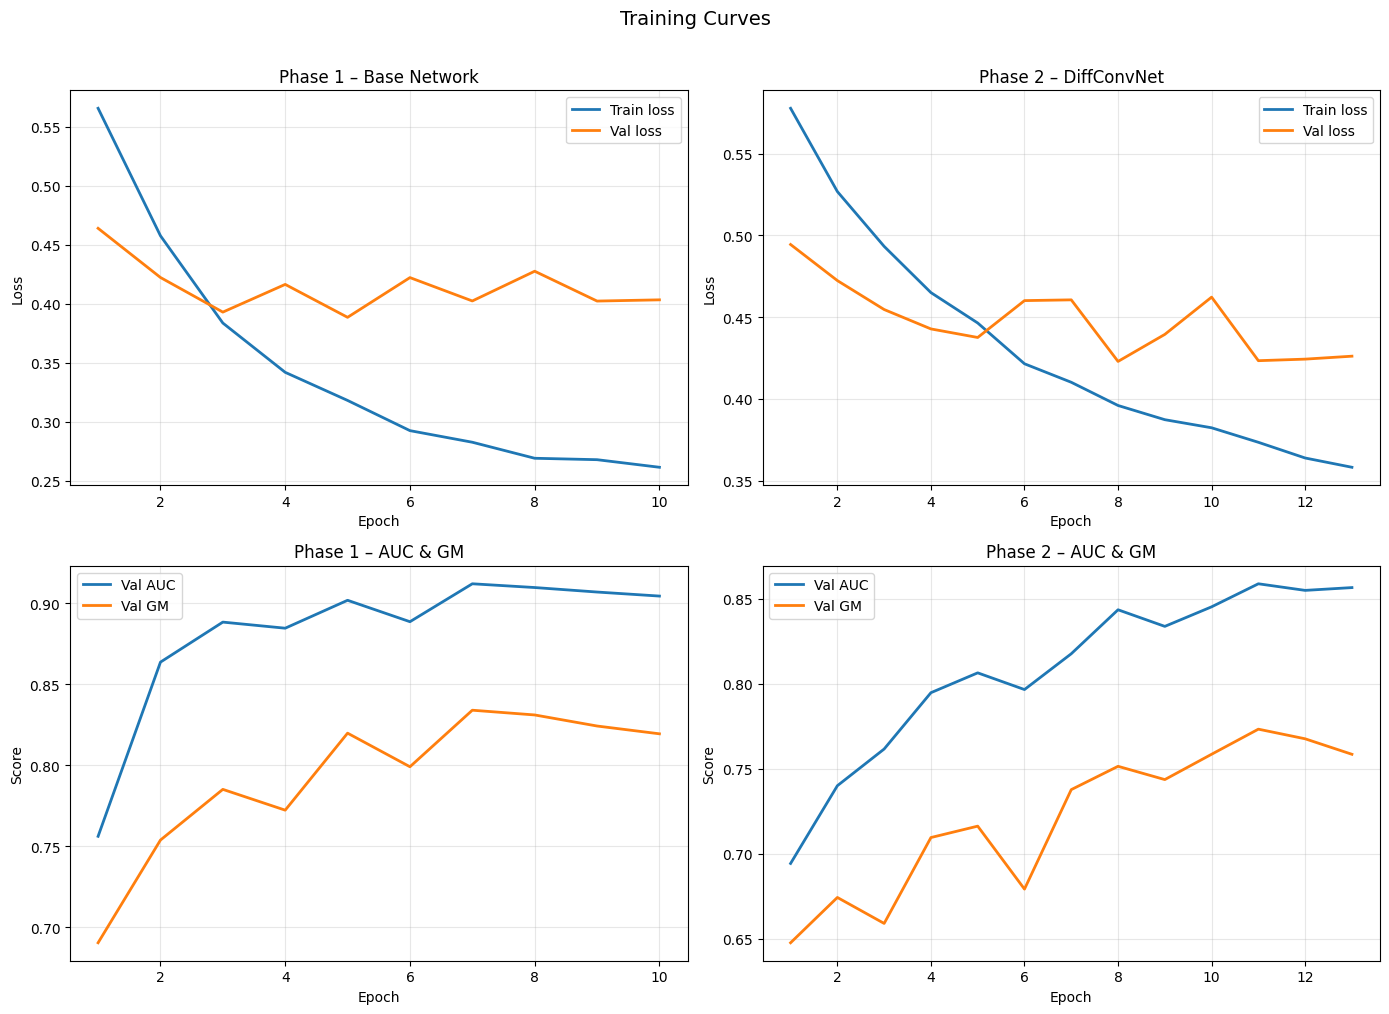

In [32]:
def plot_histories(base_history, diff_history):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for ax, (title, h) in zip(
        axes[0],
        [('Phase 1 – Base Network', base_history),
         ('Phase 2 – DiffConvNet',  diff_history)]
    ):
        ep_tr = range(1, len(h['train_loss']) + 1)
        ep_vl = range(1, len(h['val_loss'])   + 1)
        ax.plot(ep_tr, h['train_loss'], label='Train loss', linewidth=2)
        ax.plot(ep_vl, h['val_loss'],   label='Val loss',   linewidth=2)
        ax.set_title(title); ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss'); ax.legend(); ax.grid(alpha=0.3)

    for ax, (title, h) in zip(
        axes[1],
        [('Phase 1 – AUC & GM', base_history),
         ('Phase 2 – AUC & GM', diff_history)]
    ):
        ep = range(1, len(h['val_auc']) + 1)
        ax.plot(ep, h['val_auc'], label='Val AUC', linewidth=2)
        ax.plot(ep, h['val_gm'],  label='Val GM',  linewidth=2)
        ax.set_title(title); ax.set_xlabel('Epoch')
        ax.set_ylabel('Score'); ax.legend(); ax.grid(alpha=0.3)

    plt.suptitle('Training Curves', y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()


if 'base_history' in dir() and 'diff_history' in dir():
    plot_histories(base_history, diff_history)
else:
    print('Run the training cell first.')


## 10. Run Prediction

In [28]:
def predict_fake_image(image_path, model_path='diffconvnet_best.pth', device=None):
    """
    Predict whether an image is Real or Fake using the trained DiffConvNet.
    Returns dict with 'prediction' (0=real, 1=fake), 'confidence', 'prob_fake'.
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    if not os.path.exists(model_path):
        raise FileNotFoundError(f'Model not found: {model_path}')

    model = DiffConvNet(BaseNetwork(pretrained=False), n_iterations=N_DIFF)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.to(device)
    model.eval()

    if not os.path.exists(image_path):
        raise FileNotFoundError(f'Image not found: {image_path}')

    img = Image.open(image_path).convert('RGB')
    img_tensor = val_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(img_tensor)
        prob_fake  = torch.sigmoid(logits).item()
        pred_class = int(prob_fake >= 0.5)

    label = 'Fake' if pred_class == 1 else 'Real'
    print(f'Prediction: {label}  (prob_fake={prob_fake:.4f})')
    return {'prediction': pred_class, 'label': label,
            'confidence': prob_fake if pred_class == 1 else 1 - prob_fake,
            'prob_fake': prob_fake}


# Example usage:
# predict_fake_image('path/to/your/image.jpg')


## 11. Visualise Diffusion States (Figure 4)

In [29]:
def visualize_diffusion_states(image_path, model_path='diffconvnet_best.pth', device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = DiffConvNet(BaseNetwork(pretrained=False), n_iterations=N_DIFF)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.to(device)
    model.eval()

    img = Image.open(image_path).convert('RGB')
    img_tensor = val_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        x = model.sn(img_tensor)
        states = [x]
        m = model.module if hasattr(model, 'module') else model
        for layer in m.diff_net.diff_layers:   # FIX: iterate ModuleList
            x = layer(x)
            states.append(x)
        d = torch.stack(states, dim=0).mean(dim=0)

    num_plots = len(states) + 1
    fig, axes = plt.subplots(1, num_plots, figsize=(3 * num_plots, 4))

    for i, state in enumerate(states):
        fm = state.squeeze(0).mean(dim=0).cpu().numpy()
        axes[i].imshow(fm, cmap='gray')
        axes[i].set_title(f'$x_0$ (SN)' if i == 0 else f'$x_{i}$')
        axes[i].axis('off')

    d_map = d.squeeze(0).mean(dim=0).cpu().numpy()
    axes[-1].imshow(d_map, cmap='gray')
    axes[-1].set_title('Averaged $d$')
    axes[-1].axis('off')

    plt.tight_layout()
    plt.show()

# visualize_diffusion_states('path/to/image.jpg')


## 12. Grad-CAM Interpretability (Figure 3)

In [30]:
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x):
        self.model.eval()
        self.model.zero_grad()
        logits = self.model(x)
        logits[0].backward()
        grads = self.gradients.cpu().data.numpy()[0]
        acts  = self.activations.cpu().data.numpy()[0]
        weights = np.mean(grads, axis=(1, 2))
        cam = np.zeros(acts.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * acts[i]
        cam = np.maximum(cam, 0)
        if np.max(cam) != 0:
            cam /= np.max(cam)
        return cam


def generate_gradcam_plot(image_path, model_path='diffconvnet_best.pth', device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = DiffConvNet(BaseNetwork(pretrained=False), n_iterations=N_DIFF)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.to(device)

    m = model.module if hasattr(model, 'module') else model
    grad_cam = GradCAM(model, m.dn_layer4)

    original_img = Image.open(image_path).convert('RGB')
    original_resized = original_img.resize((IMG_SIZE, IMG_SIZE))
    img_tensor = val_transform(original_img).unsqueeze(0).to(device)

    cam = grad_cam(img_tensor)
    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    original_arr = np.array(original_resized)
    overlay = (original_arr * 0.5 + heatmap * 0.5).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original_arr);  axes[0].set_title('Input');      axes[0].axis('off')
    axes[1].imshow(cam_resized, cmap='jet'); axes[1].set_title('Grad-CAM'); axes[1].axis('off')
    axes[2].imshow(overlay);       axes[2].set_title('Overlay');    axes[2].axis('off')
    plt.tight_layout()
    plt.show()

# generate_gradcam_plot('path/to/image.jpg')


## 13. LIME Interpretability

In [31]:
# !pip install lime scikit-image

from lime import lime_image
from skimage.segmentation import mark_boundaries

def generate_lime_explanation(image_path, model_path='diffconvnet_best.pth',
                               device=None, num_samples=1000):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = DiffConvNet(BaseNetwork(pretrained=False), n_iterations=N_DIFF)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.to(device)
    model.eval()

    def batch_predict(images):
        batch = torch.stack([
            val_transform(Image.fromarray(img.astype(np.uint8)))
            for img in images
        ], dim=0).to(device)
        with torch.no_grad():
            logits = model(batch)
            probs_fake = torch.sigmoid(logits).cpu().numpy()
            probs_real = 1.0 - probs_fake
        return np.vstack((probs_real, probs_fake)).T

    original_img     = Image.open(image_path).convert('RGB')
    original_resized = original_img.resize((IMG_SIZE, IMG_SIZE))
    img_np           = np.array(original_resized)

    explainer   = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        img_np, batch_predict, top_labels=1, hide_color=0, num_samples=num_samples
    )

    pred_label = explanation.top_labels[0]
    temp, mask = explanation.get_image_and_mask(
        pred_label, positive_only=True, num_features=5, hide_rest=False
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_np); axes[0].set_title('Original'); axes[0].axis('off')
    lbl_name = 'Fake' if pred_label == 1 else 'Real'
    axes[1].imshow(mark_boundaries(temp / 255.0, mask))
    axes[1].set_title(f'LIME (Predicted: {lbl_name})')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

# generate_lime_explanation('path/to/image.jpg')
